# Mini-Project 2: California Housing Dataset

In [14]:
# import dataset
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

In [15]:
# print data
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

## Selecting the number of clusters

Candidate values from 2 through 10 are evaluated before fitting the final models. The silhouette score is the primary quantitative criterion because it measures both within-cluster cohesion and between-cluster separation. The inertia curve provides supporting evidence through the elbow method. The final maps should also be checked for geographic coherence and interpretability.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

clustering_features = df[["Longitude", "Latitude", "MedHouseVal"]]
scaled_features = StandardScaler().fit_transform(clustering_features)

candidate_clusters = range(2, 11)
selection_results = []

for candidate_k in candidate_clusters:
    candidate_model = KMeans(
        n_clusters=candidate_k, random_state=42, n_init=20
    )
    candidate_labels = candidate_model.fit_predict(scaled_features)
    selection_results.append(
        {
            "K": candidate_k,
            "Inertia": candidate_model.inertia_,
            "Silhouette Score": silhouette_score(
                scaled_features,
                candidate_labels,
                sample_size=5_000,
                random_state=42,
            ),
        }
    )

cluster_selection = pd.DataFrame(selection_results).set_index("K")
best_silhouette_k = int(cluster_selection["Silhouette Score"].idxmax())
selected_k = 6  # Chosen for geographic detail and regional interpretability.
print(f"Highest silhouette score: K = {best_silhouette_k}.")
print(f"Selected for the regional analysis: K = {selected_k}.")
cluster_selection.round({"Inertia": 0, "Silhouette Score": 3})

Highest silhouette score: K = 2.
Selected for the regional analysis: K = 6.


,Inertia,Silhouette Score
K,,
2,26768.0,0.545
3,18289.0,0.529
4,12109.0,0.490
5,9864.0,0.472
6,8114.0,0.415
7,6563.0,0.410
8,5796.0,0.395
9,5073.0,0.391
10,4602.0,0.390


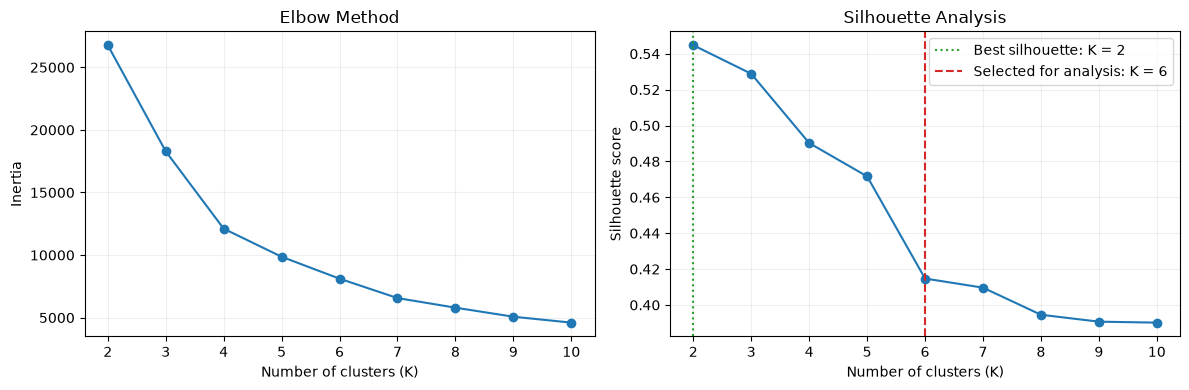

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cluster_selection.index, cluster_selection["Inertia"], marker="o")
axes[0].set(
    title="Elbow Method",
    xlabel="Number of clusters (K)",
    ylabel="Inertia",
)

axes[1].plot(
    cluster_selection.index,
    cluster_selection["Silhouette Score"],
    marker="o",
)
axes[1].axvline(
    best_silhouette_k,
    color="tab:green",
    linestyle=":",
    label=f"Best silhouette: K = {best_silhouette_k}",
)
axes[1].axvline(
    selected_k,
    color="tab:red",
    linestyle="--",
    label=f"Selected for analysis: K = {selected_k}",
)
axes[1].set(
    title="Silhouette Analysis",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xticks(list(candidate_clusters))

fig.tight_layout()
plt.show()

## Geographic price regions

The six regions below are produced by K-means clustering on the three required features: standardized longitude, latitude, and median house value. Although the highest silhouette score occurs at two clusters, six regions are used because they provide more useful geographic detail and reveal distinct price markets while remaining a small, interpretable set. The inertia and silhouette results above make this tradeoff explicit. Standardizing places the geographic coordinates and price on comparable scales so that no feature dominates merely because of its units. The fixed random seed and explicit relabeling make the region numbers reproducible; regions are numbered from north to south by their cluster centroids.

In [18]:
# k-means clustering on the California housing dataset
kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(scaled_features)

# Give the arbitrary K-means labels stable, readable region numbers.
centroids = (
    df.groupby("cluster")[["Longitude", "Latitude"]]
    .mean()
    .sort_values(["Latitude", "Longitude"], ascending=[False, True])
)
region_number = {cluster: number for number, cluster in enumerate(centroids.index, start=1)}
df["Region"] = df["cluster"].map(region_number).map(lambda number: f"Region {number}")

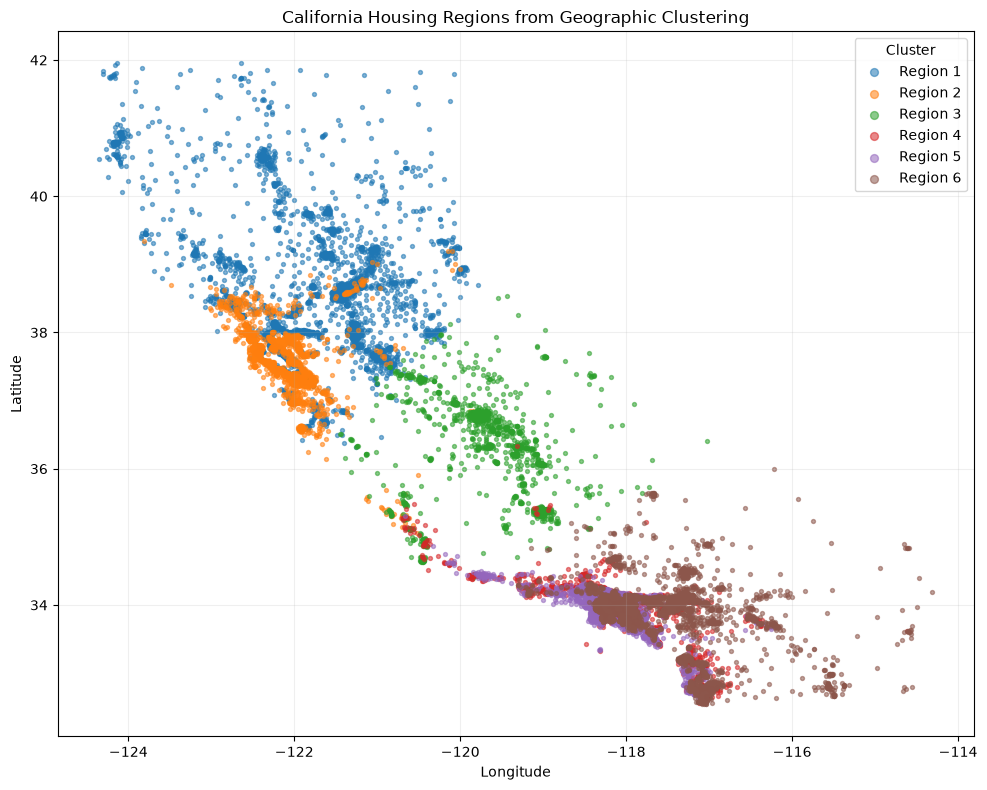

In [19]:
# show clustering results on a scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
for region, region_data in df.groupby("Region", sort=True):
    ax.scatter(
        region_data["Longitude"],
        region_data["Latitude"],
        s=8,
        alpha=0.55,
        label=region,
    )

ax.set(
    title="California Housing Regions from Geographic Clustering",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(title="Cluster", markerscale=2, frameon=True)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [20]:
region_price_summary = (
    df.groupby("Region", sort=True)
    .agg(
        Mean_Price_USD=("MedHouseVal", lambda values: values.mean() * 100_000),
        Block_Groups=("MedHouseVal", "size"),
        Centroid_Longitude=("Longitude", "mean"),
        Centroid_Latitude=("Latitude", "mean"),
    )
)

region_price_summary.style.format(
    {
        "Mean_Price_USD": "${:,.0f}",
        "Block_Groups": "{:,}",
        "Centroid_Longitude": "{:.2f}",
        "Centroid_Latitude": "{:.2f}",
    }
)

,Mean_Price_USD,Block_Groups,Centroid_Longitude,Centroid_Latitude
Region,,,,
Region 1,"$137,015","4,968",-121.82,38.40
Region 2,"$340,844","2,763",-122.15,37.58
Region 3,"$91,495","1,657",-119.69,36.25
Region 4,"$249,640","3,956",-118.17,33.91
Region 5,"$437,609","1,673",-118.24,33.90
Region 6,"$137,962","5,623",-117.66,33.77


## (Optional) Additional Clustering Methods

### Agglomerative clustering

For a direct comparison with K-means, this method uses the same three standardized features and the same number of regions. Agglomerative clustering starts with individual observations and repeatedly merges the closest groups. A 15-nearest-neighbor graph based on longitude and latitude restricts merges to geographically local observations, which supports the goal of forming contiguous market regions.

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

# Restrict possible merges to nearby geographic observations.
scaled_coordinates = StandardScaler().fit_transform(df[["Longitude", "Latitude"]])
geographic_connectivity = kneighbors_graph(
    scaled_coordinates, n_neighbors=15, include_self=False
)

agglomerative = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="ward",
    connectivity=geographic_connectivity,
)
df["agglomerative_cluster"] = agglomerative.fit_predict(scaled_features)

agglomerative_centroids = (
    df.groupby("agglomerative_cluster")[["Longitude", "Latitude"]]
    .mean()
    .sort_values(["Latitude", "Longitude"], ascending=[False, True])
)
agglomerative_region_number = {
    cluster: number
    for number, cluster in enumerate(agglomerative_centroids.index, start=1)
}
df["Agglomerative Region"] = (
    df["agglomerative_cluster"]
    .map(agglomerative_region_number)
    .map(lambda number: f"Region {number}")
)

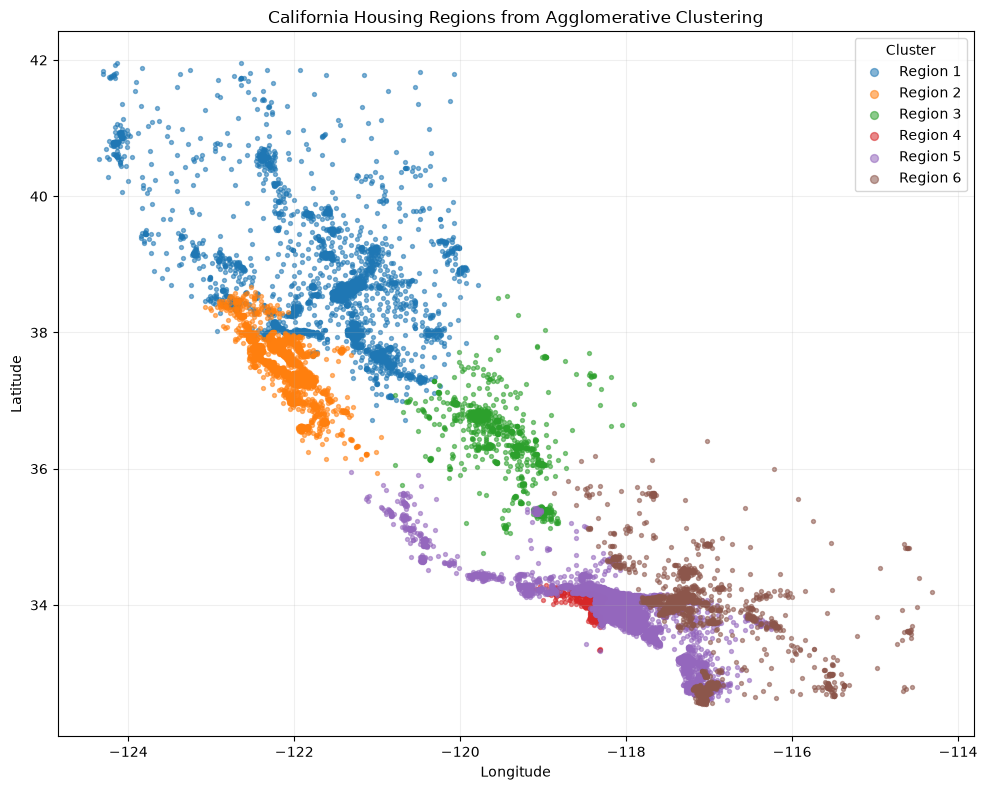

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
for region, region_data in df.groupby("Agglomerative Region", sort=True):
    ax.scatter(
        region_data["Longitude"],
        region_data["Latitude"],
        s=8,
        alpha=0.55,
        label=region,
    )

ax.set(
    title="California Housing Regions from Agglomerative Clustering",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(title="Cluster", markerscale=2, frameon=True)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [23]:
agglomerative_price_summary = (
    df.groupby("Agglomerative Region", sort=True)
    .agg(
        Mean_Price_USD=("MedHouseVal", lambda values: values.mean() * 100_000),
        Block_Groups=("MedHouseVal", "size"),
        Centroid_Longitude=("Longitude", "mean"),
        Centroid_Latitude=("Latitude", "mean"),
    )
)

agglomerative_price_summary.style.format(
    {
        "Mean_Price_USD": "${:,.0f}",
        "Block_Groups": "{:,}",
        "Centroid_Longitude": "{:.2f}",
        "Centroid_Latitude": "{:.2f}",
    }
)

,Mean_Price_USD,Block_Groups,Centroid_Longitude,Centroid_Latitude
Agglomerative Region,,,,
Region 1,"$126,648","3,823",-121.67,38.67
Region 2,"$284,349","4,018",-122.15,37.56
Region 3,"$81,359","1,266",-119.50,36.37
Region 4,"$401,164","1,155",-118.43,34.02
Region 5,"$222,772","8,205",-118.14,33.90
Region 6,"$114,417","2,173",-117.12,33.69


### Gaussian mixture model

This standard Gaussian mixture model uses the same three standardized features and the selected number of components for comparison with K-means. It permits clusters with different covariance structures and assigns observations probabilistically, but it does not enforce geographic contiguity.

In [24]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=selected_k,
    covariance_type="full",
    n_init=10,
    random_state=42,
)
df["gmm_cluster"] = gmm.fit_predict(scaled_features)

gmm_centroids = (
    df.groupby("gmm_cluster")[["Longitude", "Latitude"]]
    .mean()
    .sort_values(["Latitude", "Longitude"], ascending=[False, True])
)
gmm_region_number = {
    cluster: number for number, cluster in enumerate(gmm_centroids.index, start=1)
}
df["GMM Region"] = (
    df["gmm_cluster"]
    .map(gmm_region_number)
    .map(lambda number: f"Region {number}")
)

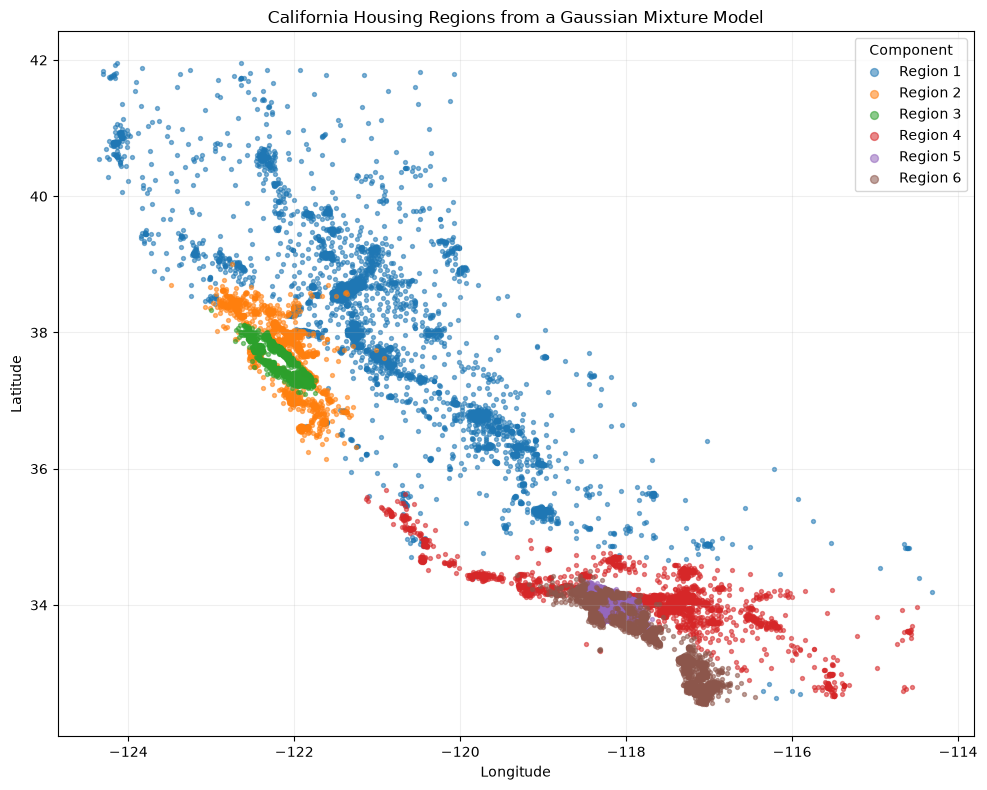

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
for region, region_data in df.groupby("GMM Region", sort=True):
    ax.scatter(
        region_data["Longitude"],
        region_data["Latitude"],
        s=8,
        alpha=0.55,
        label=region,
    )

ax.set(
    title="California Housing Regions from a Gaussian Mixture Model",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(title="Component", markerscale=2, frameon=True)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [26]:
gmm_price_summary = (
    df.groupby("GMM Region", sort=True)
    .agg(
        Mean_Price_USD=("MedHouseVal", lambda values: values.mean() * 100_000),
        Block_Groups=("MedHouseVal", "size"),
        Centroid_Longitude=("Longitude", "mean"),
        Centroid_Latitude=("Latitude", "mean"),
    )
)

gmm_price_summary.style.format(
    {
        "Mean_Price_USD": "${:,.0f}",
        "Block_Groups": "{:,}",
        "Centroid_Longitude": "{:.2f}",
        "Centroid_Latitude": "{:.2f}",
    }
)

,Mean_Price_USD,Block_Groups,Centroid_Longitude,Centroid_Latitude
GMM Region,,,,
Region 1,"$107,500","4,750",-120.85,37.93
Region 2,"$251,419","2,038",-122.17,37.72
Region 3,"$285,703","2,561",-122.19,37.60
Region 4,"$171,179","2,634",-117.92,34.14
Region 5,"$188,895","5,088",-118.17,33.98
Region 6,"$308,998","3,569",-117.71,33.44
